# Displacement Orders Data EDA notebook

> In this notebook, we will explore displacement orders to:
>  * uncover patterns.
> * identify trends. 
> * gain insights into their impact on the people of Gaza.

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
import os

os.chdir("C:/Guest/15-Career/MIT-Emrging Talent Program/ET6-CDSP-group-03-repo")

In [4]:
ocha_data = pd.read_csv(
    "1_datasets/data/clean_datasets/idmc_event_data_for_pse_cleaned.csv"
)
gazamap_data = pd.read_csv(
    "1_datasets/data/clean_datasets/gaza_displacement_cleaned.csv"
)

### General Trends & Overview

In [8]:
gazamap_data["date"] = pd.to_datetime(gazamap_data["date"])
ocha_data["displacement_date"] = pd.to_datetime(ocha_data["displacement_date"])

In [9]:
gazamap_data.sort_values(by="date", inplace=True)
ocha_data.sort_values(by="displacement_date", inplace=True)

### 1. How many displacement orders were issued over time (daily/weekly)?

In [10]:
gazamap_data["displacement_year"] = gazamap_data["date"].dt.year
gazamap_data["displacement_month"] = gazamap_data["date"].dt.month
gazamap_data["displacement_day"] = gazamap_data["date"].dt.day

In [11]:
dates_groups = (
    gazamap_data.groupby(
        ["displacement_year", "displacement_month", "displacement_day", "date"]
    )
    .agg({"id": "count"})
    .reset_index()
)
dates_groups.rename({"id": "num_orders"}, axis=1, inplace=True)

In [19]:
dates = [
    pd.to_datetime(f"{x.month}-{x.year}", format="%m-%Y")
    for x in pd.date_range(
        gazamap_data["date"].min(), gazamap_data["date"].max(), freq="W"
    ).to_list()
]

In [20]:
dates

[Timestamp('2023-10-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2023-11-01 00:00:00'),
 Timestamp('2023-11-01 00:00:00'),
 Timestamp('2023-11-01 00:00:00'),
 Timestamp('2023-11-01 00:00:00'),
 Timestamp('2023-12-01 00:00:00'),
 Timestamp('2023-12-01 00:00:00'),
 Timestamp('2023-12-01 00:00:00'),
 Timestamp('2023-12-01 00:00:00'),
 Timestamp('2023-12-01 00:00:00'),
 Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-02-01 00:00:00'),
 Timestamp('2024-02-01 00:00:00'),
 Timestamp('2024-02-01 00:00:00'),
 Timestamp('2024-02-01 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2024-04-

C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\655566897.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[1][4] >= 2:
C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\655566897.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[1][3], row[1][3] + pd.DateOffset(weeks=1), color="yellow", alpha=0.2


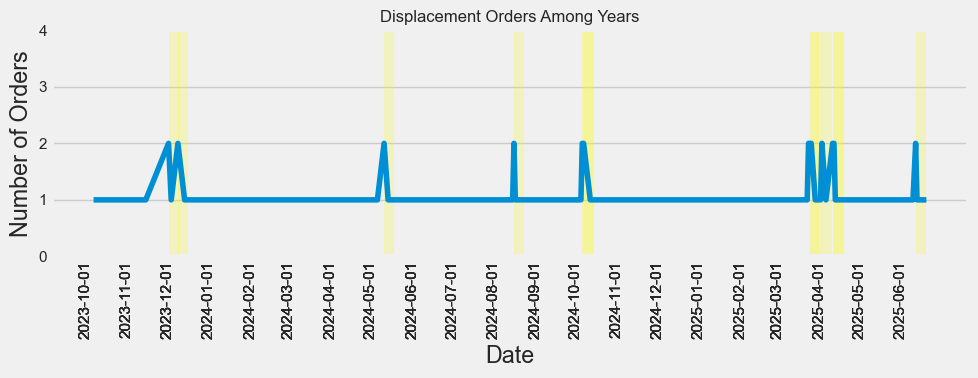

In [23]:
y_max = dates_groups.num_orders.max()
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for row in dates_groups.iterrows():
        if row[1][4] >= 2:
            plt.axvspan(
                row[1][3], row[1][3] + pd.DateOffset(weeks=1), color="yellow", alpha=0.2
            )

    sns.lineplot(data=dates_groups, x="date", y="num_orders", markersize=3, ax=ax)
    plt.title("Displacement Orders Among Years", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    plt.yticks(range(0, int(y_max) + 3))
    plt.xticks(dates, rotation="vertical")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

### Affected area time trend

C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\2677645643.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[1][9] >= 50:
C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\2677645643.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[1][1], row[1][1] + pd.DateOffset(days=3), color="yellow", alpha=0.3
C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\2677645643.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_displ

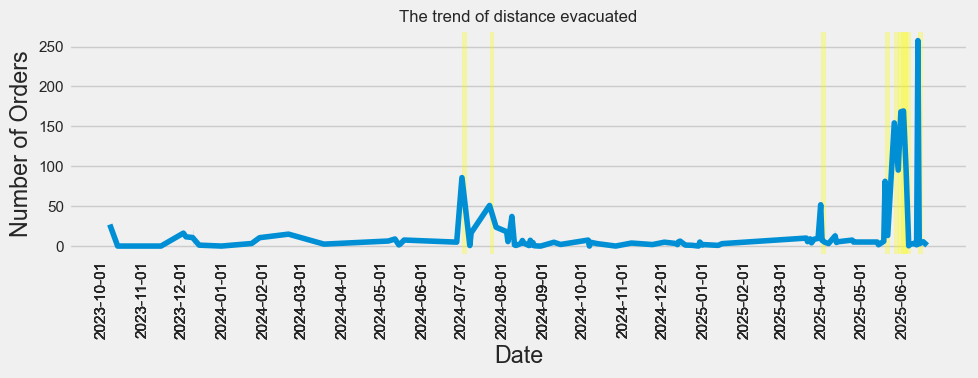

In [ ]:
y_max = gazamap_data.area_sq_km_displacement.max()
most_displacement_areas = []
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    for row in gazamap_data.iterrows():
        if row[1][9] >= 50:  # putting a threshold with 50 km distance of evacuation
            plt.axvspan(
                row[1][1], row[1][1] + pd.DateOffset(days=3), color="yellow", alpha=0.3
            )
            most_displacement_areas.append(row[1][1])

    sns.lineplot(data=gazamap_data, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    # plt.yticks(range(0, int(y_max) + 3))
    plt.xticks(dates, rotation="vertical")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

Zoom in the most evacuated area dates

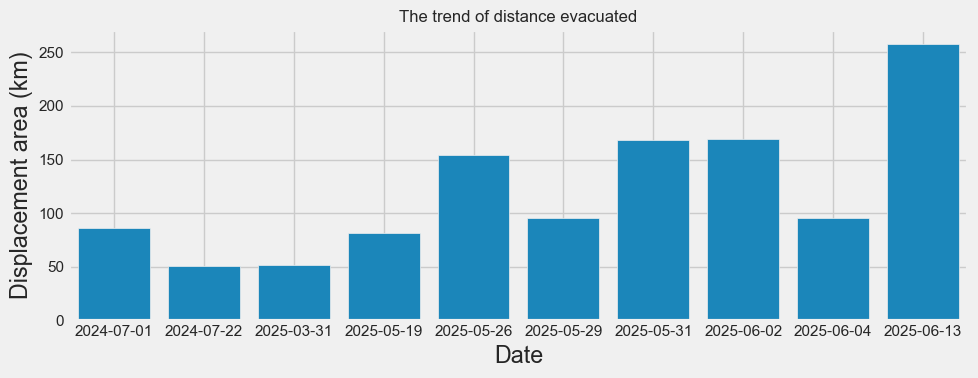

In [107]:
most_displaced_df = gazamap_data[gazamap_data["date"].isin(most_displacement_areas)]
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    sns.barplot(data=most_displaced_df, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Displacement area (km)")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

### Search for each displacement order how much area where effected

### Is there a trend on the week day of displacement order?

In [126]:
gazamap_data["displacement_week_day_num"] = gazamap_data["date"].dt.weekday

In [127]:
day_names_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
gazamap_data["displacement_week_day"] = gazamap_data["displacement_week_day_num"].map(
    day_names_map
)

In [ ]:
gazamap_data["is_work_day"] = np.where(
    gazamap_data["displacement_week_day"].isin(
        ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    ),
    "Yes",
    "No",
)

In [137]:
gazamap_data[["is_work_day", "displacement_week_day"]]

,is_work_day,displacement_week_day
108,Yes,Saturday
107,No,Friday
106,Yes,Wednesday
105,Yes,Saturday
104,Yes,Saturday
...,...,...
4,Yes,Thursday
3,No,Friday
2,Yes,Saturday
1,Yes,Tuesday


In [118]:
week_day_groups = (
    gazamap_data.groupby("displacement_week_day")
    .agg({"id": "count"})
    .reset_index()
    .rename(columns={"id": "num_orders"})
)

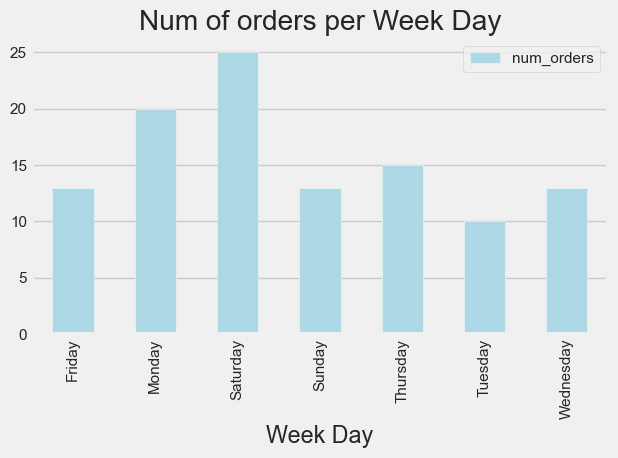

In [121]:
with plt.style.context("fivethirtyeight"):
    colors = ["lightblue"]
    week_day_groups.plot(
        kind="bar", x="displacement_week_day", y="num_orders", color=colors
    )
    plt.xlabel("Week Day")
    plt.title("Num of orders per Week Day")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

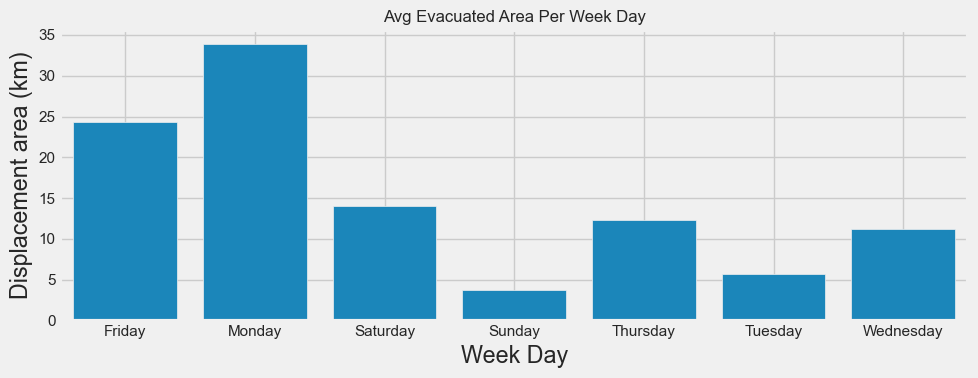

In [161]:
week_days_displacement = gazamap_data.groupby(
    "displacement_week_day", as_index=False
).agg(avg_evacuated_area=("area_sq_km_displacement", "mean"))
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    sns.barplot(
        data=week_days_displacement,
        x="displacement_week_day",
        y="avg_evacuated_area",
        ax=ax,
    )
    plt.title("Avg Evacuated Area Per Week Day", fontsize=12)
    plt.xlabel("Week Day")
    plt.ylabel("Displacement area (km)")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

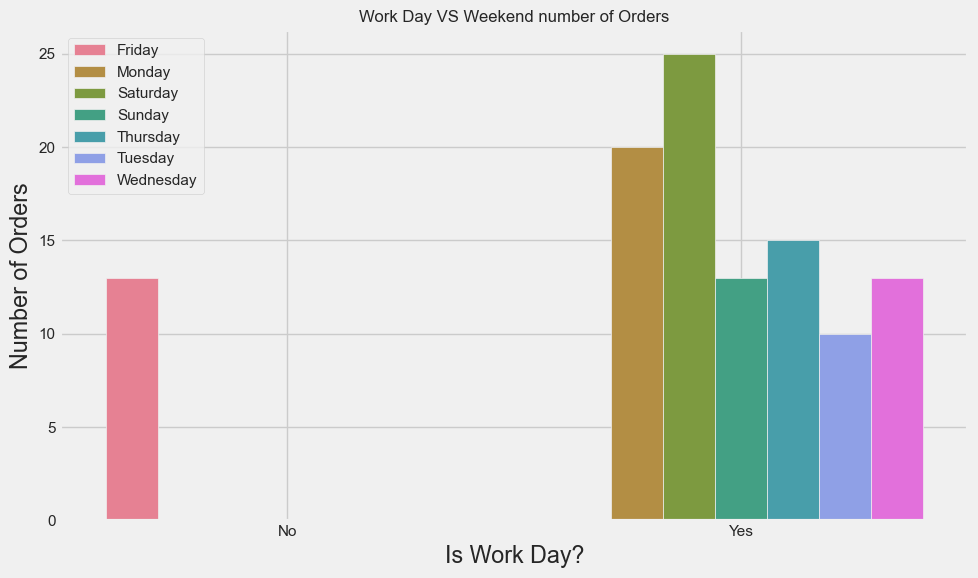

In [151]:
day_type_groups = (
    gazamap_data.groupby(["is_work_day", "displacement_week_day"])
    .agg({"id": "count"})
    .reset_index()
    .rename(columns={"id": "num_orders"})
)
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 6))
    sns.barplot(
        data=day_type_groups,
        x="is_work_day",
        y="num_orders",
        hue="displacement_week_day",
        ax=ax,
    )
    plt.title("Work Day VS Weekend number of Orders", fontsize=12)
    plt.xlabel("Is Work Day?")
    plt.ylabel("Number of Orders")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.legend(loc="upper left")
    plt.show()

### Key finding: As the most of orders were issued on the work days (according to arabic calendar) so that affects students performance for sure, because majority of exams, activites, sessions will be issued from Saturday-Thursday (Friday is the weekend) espacially on IUG

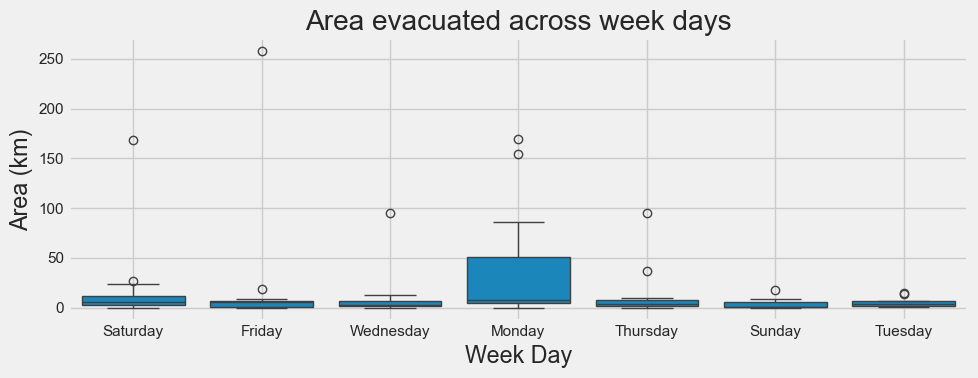

In [124]:
with plt.style.context("fivethirtyeight"):
    fig, axes = plt.subplots(nrows=1, figsize=(10, 4))
    sns.boxplot(
        data=gazamap_data,
        x="displacement_week_day",
        y="area_sq_km_displacement",
        ax=axes,
    )
    plt.xlabel("Week Day")
    plt.ylabel("Area (km)")
    plt.title("Area evacuated across week days")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

In [152]:
gazamap_data.columns

Index(['id', 'date', 'source', 'link', 'map_idf', 'map_full', 'map_zoom',
       'displacement_blocks', 'labeled_safe_blocks', 'area_sq_km_displacement',
       'area_sq_km_labeled_safe', 'displacement_year', 'displacement_month',
       'displacement_day', 'displacement_week_day',
       'displacement_week_day_num', 'is_work_day'],
      dtype='object')

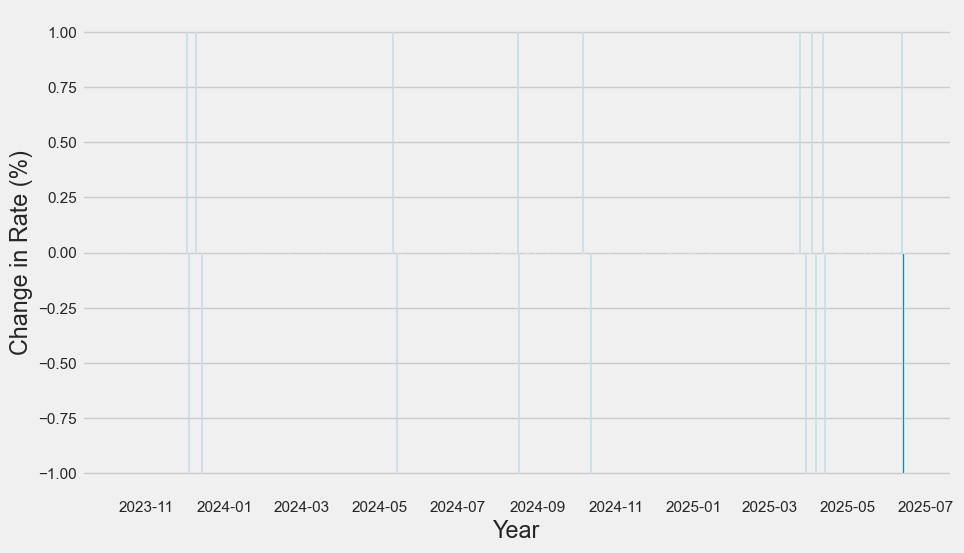

In [156]:
monthly_order_num_change = gazamap_data.groupby(["date"])["id"].count()
monthly_order_num_change = (
    monthly_order_num_change.diff().reset_index()
)  # Calculate year-over-year change

with plt.style.context("fivethirtyeight"):
    # Plot the annual change
    plt.figure(figsize=(10, 6))
    plt.bar(
        monthly_order_num_change["date"], monthly_order_num_change["id"]
    )  # , color='skyblue', edgecolor='black')
    # plt.title("Annual Change in Unemployment Rate in the US (1950-2024)")
    plt.xlabel("Year")
    # plt.xlim(df_melted["Date"].min(), df_melted["Date"].max())
    plt.ylabel("Change in Rate (%)")
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.title(title)
    # plt.xlabel(date)
    plt.grid(axis="x")

    # plt.ylim(-1, 16)
    # plt.xlim(annual_change["Year"].min(), annual_change["Year"].max()+1)
    # plt.tight_layout()
    plt.show()

### 2.What is the geographical distribution of displacement orders?

In [106]:
gaza_data = ocha_data[ocha_data["locations_name"].str.contains("Gaza")]

In [55]:
import plotly.express as px

fig = px.scatter_mapbox(
    gaza_data, lat="latitude", lon="longitude", color="figure", zoom=10, height=500
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [263]:
gaza_data.columns

Index(['id', 'country', 'iso3', 'latitude', 'longitude', 'centroid', 'role',
       'displacement_type', 'qualifier', 'figure', 'displacement_date',
       'displacement_start_date', 'displacement_end_date', 'year', 'event_id',
       'event_name', 'event_start_date', 'event_end_date', 'sources',
       'source_url', 'locations_name', 'locations_coordinates',
       'locations_accuracy', 'locations_type', 'displacement_occurred',
       'created_at', 'description', 'link', 'combined_type'],
      dtype='object')

## Population Impact

### 1. How many people were affected per displacement order?

In [56]:
gaza_data.qualifier

0                     total
1                     total
2                     total
3                     total
4                     total
5                     total
6                     total
7                     total
8                     total
9                     total
10                    total
11                    total
12                    total
14                    total
16                    total
18                    total
19                    total
20                    total
21                    total
22                    total
23    more than or equal to
24                    total
Name: qualifier, dtype: object

In [31]:
gaza_data.displacement_date.max()

'2025-05-27'

In [34]:
gazamap_data[
    (gazamap_data["date"] >= "2025-03-18") & (gazamap_data["date"] <= "2025-05-27")
].shape

(27, 14)

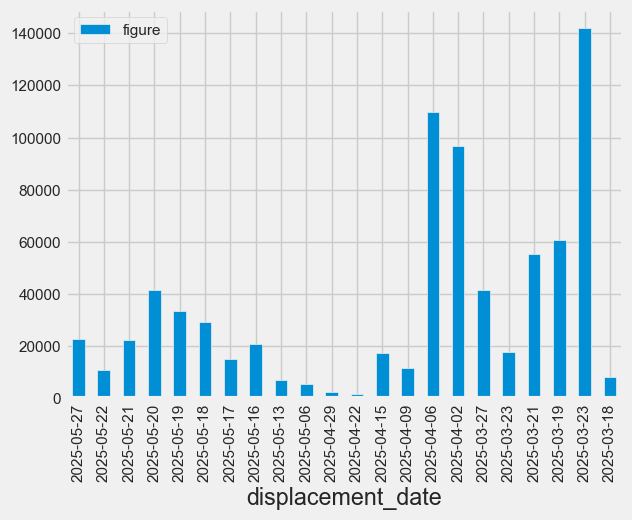

In [24]:
with plt.style.context("fivethirtyeight"):
    gaza_data.plot(kind="bar", x="displacement_date", y="figure")
    plt.show()